<a href="https://colab.research.google.com/github/Mayar-alsulami/Final_Project/blob/main/01_cleaning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import zipfile
from google.colab import files

uploaded = files.upload()

with zipfile.ZipFile('archive (4).zip', 'r') as zip_ref:
    zip_ref.extractall()

df = pd.read_csv('openpowerlifting.csv')
df.head()

Saving archive (4).zip to archive (4).zip


,MeetID,Name,Sex,Equipment,Age,Division,BodyweightKg,WeightClassKg,Squat4Kg,BestSquatKg,Bench4Kg,BestBenchKg,Deadlift4Kg,BestDeadliftKg,TotalKg,Place,Wilks
0,0,Angie Belk Terry,F,Wraps,47.0,Mst 45-49,59.60,60,NaN,47.63,NaN,20.41,NaN,70.31,138.35,1,155.05
1,0,Dawn Bogart,F,Single-ply,42.0,Mst 40-44,58.51,60,NaN,142.88,NaN,95.25,NaN,163.29,401.42,1,456.38
2,0,Dawn Bogart,F,Single-ply,42.0,Open Senior,58.51,60,NaN,142.88,NaN,95.25,NaN,163.29,401.42,1,456.38
3,0,Dawn Bogart,F,Raw,42.0,Open Senior,58.51,60,NaN,NaN,NaN,95.25,NaN,NaN,95.25,1,108.29
4,0,Destiny Dula,F,Raw,18.0,Teen 18-19,63.68,67.5,NaN,NaN,NaN,31.75,NaN,90.72,122.47,1,130.47


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 386414 entries, 0 to 386413
Data columns (total 17 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   MeetID          386414 non-null  int64  
 1   Name            386414 non-null  object 
 2   Sex             386414 non-null  object 
 3   Equipment       386414 non-null  object 
 4   Age             147147 non-null  float64
 5   Division        370571 non-null  object 
 6   BodyweightKg    384012 non-null  float64
 7   WeightClassKg   382602 non-null  object 
 8   Squat4Kg        1243 non-null    float64
 9   BestSquatKg     298071 non-null  float64
 10  Bench4Kg        1962 non-null    float64
 11  BestBenchKg     356364 non-null  float64
 12  Deadlift4Kg     2800 non-null    float64
 13  BestDeadliftKg  317847 non-null  float64
 14  TotalKg         363237 non-null  float64
 15  Place           385322 non-null  object 
 16  Wilks           362194 non-null  float64
dtypes: float64

In [ ]:
def convert (df):
    df['Age'] = pd.to_numeric(df['Age'], errors='coerce').round(0).astype('Int64')
    return df
df = convert(df)
print(df.dtypes)

MeetID              int64
Name               object
Sex                object
Equipment          object
Age                 Int64
Division           object
BodyweightKg      float64
WeightClassKg      object
Squat4Kg          float64
BestSquatKg       float64
Bench4Kg          float64
BestBenchKg       float64
Deadlift4Kg       float64
BestDeadliftKg    float64
TotalKg           float64
Place              object
Wilks             float64
dtype: object


In [ ]:
def drop(df):
  # Dropping columns that we don't need
  global df_dropping
  df_dropping = df.drop(columns=['Squat4Kg','Bench4Kg','Deadlift4Kg','WeightClassKg','Division'], errors='ignore')
  return df_dropping
df = drop(df)
print(df.columns)


Index(['MeetID', 'Name', 'Sex', 'Equipment', 'Age', 'BodyweightKg',
       'BestSquatKg', 'BestBenchKg', 'BestDeadliftKg', 'TotalKg', 'Place',
       'Wilks'],
      dtype='object')


In [ ]:
def fill(df):
    df['Age'] = df['Age'].fillna(df['Age'].median())
    return df      # we filled the missiing values in the age column using the median
df = fill(df)
print(df.isnull().sum())


MeetID                0
Name                  0
Sex                   0
Equipment             0
Age                   0
BodyweightKg       2402
BestSquatKg       88343
BestBenchKg       30050
BestDeadliftKg    68567
TotalKg           23177
Place              1092
Wilks             24220
dtype: int64


In [ ]:
def dropping_rows(df):
  df = df.dropna(subset=['TotalKg','BodyweightKg'])  # dropping the rows with missingness
  return df
df = dropping_rows(df)
print(df.isnull().sum())
dropping_rows(df)

MeetID                0
Name                  0
Sex                   0
Equipment             0
Age                   0
BodyweightKg          0
BestSquatKg       74682
BestBenchKg       14468
BestDeadliftKg    50880
TotalKg               0
Place              1089
Wilks                 0
dtype: int64


,MeetID,Name,Sex,Equipment,Age,BodyweightKg,BestSquatKg,BestBenchKg,BestDeadliftKg,TotalKg,Place,Wilks
0,0,Angie Belk Terry,F,Wraps,47,59.60,47.63,20.41,70.31,138.35,1,155.05
1,0,Dawn Bogart,F,Single-ply,42,58.51,142.88,95.25,163.29,401.42,1,456.38
2,0,Dawn Bogart,F,Single-ply,42,58.51,142.88,95.25,163.29,401.42,1,456.38
3,0,Dawn Bogart,F,Raw,42,58.51,NaN,95.25,NaN,95.25,1,108.29
4,0,Destiny Dula,F,Raw,18,63.68,NaN,31.75,90.72,122.47,1,130.47
...,...,...,...,...,...,...,...,...,...,...,...,...
386409,8481,William Barabas,M,Multi-ply,28,113.58,NaN,NaN,347.50,347.50,2,202.60
386410,8481,Justin Zottl,M,Multi-ply,28,119.02,NaN,NaN,322.50,322.50,3,185.77
386411,8481,Jake Anderson,M,Multi-ply,28,120.29,NaN,NaN,367.50,367.50,1,211.17
386412,8481,Jeff Bumanglag,M,Multi-ply,28,126.73,NaN,NaN,320.00,320.00,3,181.85


In [ ]:
def dropping_dub(df):
    df = df.drop_duplicates()
    return df
df = dropping_dub(df)    # calling the function that removes the dublicated values
print(df.duplicated().sum())   # results: no dublicated values

0


Text(0.5, 1.0, 'Identifying outliers in TotalKg')

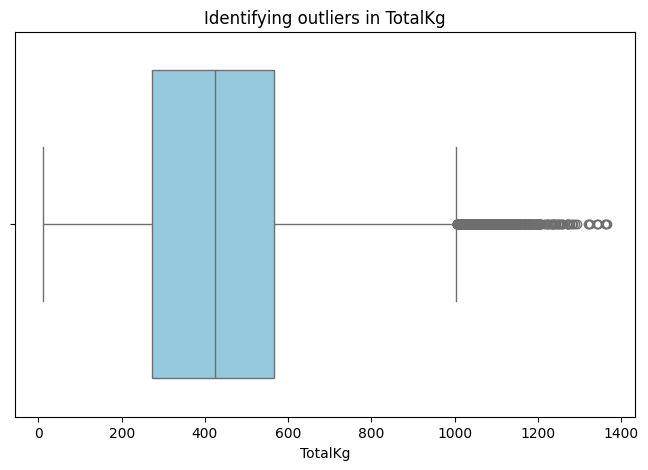

In [ ]:
plt.figure(figsize=(8, 5))
sns.boxplot(x=df['TotalKg'], color='skyblue')    #look at the massive amount of outliers we have to handle that
plt.title('Identifying outliers in TotalKg')

In [ ]:
def cap_outliers_totalkg(df):
    # Calculate limits
    upper_limit = df['TotalKg'].quantile(0.99)
    lower_limit = df['TotalKg'].quantile(0.01)

    # Print info
    print(f"99th Percentile cap: {upper_limit:.2f} kg")
    print(f"1st Percentile cap: {lower_limit:.2f} kg")

    # Apply capping
    df['TotalKg'] = df['TotalKg'].clip(lower=lower_limit, upper=upper_limit)

    # Summary
    print(df['TotalKg'].describe())

    return df
cap_outliers_totalkg(df)

99th Percentile cap: 891.31 kg
1st Percentile cap: 60.00 kg
count    353773.000000
mean        423.839198
std         192.895981
min          60.000000
25%         272.500000
50%         425.000000
75%         565.000000
max         891.310000
Name: TotalKg, dtype: float64


,MeetID,Name,Sex,Equipment,Age,BodyweightKg,BestSquatKg,BestBenchKg,BestDeadliftKg,TotalKg,Place,Wilks
0,0,Angie Belk Terry,F,Wraps,47,59.60,47.63,20.41,70.31,138.35,1,155.05
1,0,Dawn Bogart,F,Single-ply,42,58.51,142.88,95.25,163.29,401.42,1,456.38
3,0,Dawn Bogart,F,Raw,42,58.51,NaN,95.25,NaN,95.25,1,108.29
4,0,Destiny Dula,F,Raw,18,63.68,NaN,31.75,90.72,122.47,1,130.47
5,0,Courtney Norris,F,Wraps,28,62.41,170.10,77.11,145.15,392.36,1,424.40
...,...,...,...,...,...,...,...,...,...,...,...,...
386409,8481,William Barabas,M,Multi-ply,28,113.58,NaN,NaN,347.50,347.50,2,202.60
386410,8481,Justin Zottl,M,Multi-ply,28,119.02,NaN,NaN,322.50,322.50,3,185.77
386411,8481,Jake Anderson,M,Multi-ply,28,120.29,NaN,NaN,367.50,367.50,1,211.17
386412,8481,Jeff Bumanglag,M,Multi-ply,28,126.73,NaN,NaN,320.00,320.00,3,181.85


In [ ]:
# Calculate limits directly in this cell
upper_limit = df['TotalKg'].quantile(0.99)
lower_limit = df['TotalKg'].quantile(0.01)

# Apply capping to the TotalKg column directly
df['TotalKg'] = df['TotalKg'].clip(lower=lower_limit, upper=upper_limit)

# No need to drop 'TotalKg_Capped' as it's not created as a separate column here.

In [ ]:
def double_check(df):
    print("\nFINAL CHECKS:")

    # Keep only required columns
    df = df[['Age', 'Sex','Equipment', 'BodyweightKg', 'TotalKg']]

    # 1. No nulls
    assert df.isnull().sum().sum() == 0, "Null values found!"

    print("No nulls")

    # 2. Target > 0
    assert (df['TotalKg'] > 0).all(), "Invalid TotalKg values!"

    print("TotalKg is valid")

    # 3. Correct columns
    assert df.shape[1] == 5, "Incorrect number of columns!"

    print("Correct number of columns")

    print("\nALL CHECKS PASSED")

    return df
df = double_check(df)


FINAL CHECKS:
No nulls
TotalKg is valid
Correct number of columns

ALL CHECKS PASSED


In [ ]:
import pandas as pd

df = pd.read_csv('openpowerlifting.csv')

def clean_pipeline(df):
    print("Starting data cleaning pipeline...")

    # Create a copy to ensure all modifications are applied sequentially to this version
    # and to avoid issues with in-place modifications vs. new DataFrame returns.
    processed_df = df.copy()

    # Step 1: Convert types
    processed_df = convert(processed_df)
    print("Step 1: Age column converted.")

    # Step 2: Drop unnecessary columns
    processed_df = drop(processed_df)
    print("Step 2: Unnecessary columns dropped.")

    # Step 3: Fill missing values
    # The 'fill' function modifies the DataFrame in place but returns a Series.
    # By assigning its return to '_', we ensure 'processed_df' remains a DataFrame for subsequent steps.
    _ = fill(processed_df)
    print("Step 3: Missing Age values filled.")

    # Step 4: Drop unwanted rows
    processed_df = dropping_rows(processed_df)
    print("Step 4: Rows with missing TotalKg or BodyweightKg dropped.")

    # Step 5: Remove duplicates
    processed_df = dropping_dub(processed_df)
    print("Step 5: Duplicate rows removed.")

    # Step 7: Cap extreme values
    processed_df = cap_outliers_totalkg(processed_df)
    print("Step 7: Extreme values in TotalKg capped.")

    # Step 8: double check
    processed_df = double_check(processed_df)
    print("Step 8: Final checks completed.")

    print("Data cleaning pipeline completed!")

    # Return the single, fully processed DataFrame
    return processed_df

# Call the master function with the DataFrame 'df'
df = clean_pipeline(df)



Starting data cleaning pipeline...
Step 1: Age column converted.
Step 2: Unnecessary columns dropped.
Step 3: Missing Age values filled.
Step 4: Rows with missing TotalKg or BodyweightKg dropped.
Step 5: Duplicate rows removed.
99th Percentile cap: 891.31 kg
1st Percentile cap: 60.00 kg
count    353773.000000
mean        423.839198
std         192.895981
min          60.000000
25%         272.500000
50%         425.000000
75%         565.000000
max         891.310000
Name: TotalKg, dtype: float64
Step 7: Extreme values in TotalKg capped.

FINAL CHECKS:
No nulls
TotalKg is valid
Correct number of columns

ALL CHECKS PASSED
Step 8: Final checks completed.
Data cleaning pipeline completed!


In [ ]:
df.to_csv("openpowerlifting_cleaned.csv", index=False)